In [4]:
import os

In [2]:
! pip install langchain langchain-groq langchain-huggingface  langchain-community langgraph python-dotenv faiss-cpu pypdf langchain-core langchain-classic 


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\rahul\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [10]:
from langchain_core.tools import tool
from langgraph.graph.state import StateGraph,START,END
from langgraph.prebuilt import tools_condition,ToolNode
from langgraph.graph.message import BaseMessage,add_messages
from langgraph.types import interrupt,Command
from langchain_core.messages import AnyMessage,AIMessage,HumanMessage
from typing import TypedDict,Annotated
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
groq_api_key=os.getenv("GROQ_API_KEY")


In [7]:
llm=ChatGroq(model="llama-3.1-8b-instant",api_key=groq_api_key)

In [2]:
class Chatstate(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [31]:
def chat_node(state:Chatstate):
    
    decision=interrupt({
        'type':'approval',
        'reason':'Model is about to answer user question',
        'question':state['messages'][-1].content,
        'instruction':'Approved the question(yes/no)?'

    })

    if decision['approved'] == "no":
        return {"messages":[AIMessage(content="Not Approved")]}
    else:
        response= llm.invoke(state['messages'])
        return {'messages':[response]}

In [32]:
checkpointer=MemorySaver()

In [33]:
config={'configurable':{'thread_id':'1234'}}

In [34]:
graph=StateGraph(Chatstate)
graph.add_node('chat_node',chat_node)
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

builder=graph.compile(checkpointer=checkpointer)

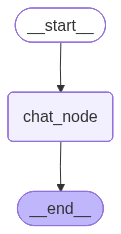

In [35]:
builder

In [36]:
intial_input={
    "messages":[("user", "Explain gradient descent in very simple terms.")]
}
result=builder.invoke(intial_input,config=config)


In [37]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='950212a1-bcf0-4e71-9bdb-6377dabf66f3')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer user question', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approved the question(yes/no)?'}, id='e2306c804a418846f9b4316c639a8dcc')]}

In [38]:
message=result['__interrupt__'][0].value

In [39]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [40]:
final_result=builder.invoke(
    Command(resume={"approved":user_input}),
    config=config
)

In [41]:
print(final_result["messages"][-1].content)

Not Approved
